In [1]:
# ============================================================
# KARNATAKA DISTRICT DEVELOPMENT INDEX
# A Data-Driven Analysis of 31 Districts
# Author: Rohan Shetty
# MSc Business Analytics | 
# Date: September 2026
# ============================================================

# Section 1 — Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import os

os.environ['LOKY_MAX_CPU_COUNT'] = '1'

print("All libraries imported successfully!")
print("Project: Karnataka District Development Index")
print("Author : Rohan Shetty | MSc Business Analytics ")

All libraries imported successfully!
Project: Karnataka District Development Index
Author : Rohan Shetty | MSc Business Analytics 


In [2]:
# ============================================================
# Section 2 — Data Loading
# ============================================================

# Load all 7 datasets
gddp      = pd.read_csv('ka_districts-gddp-pci-2025-26.csv')
msme      = pd.read_csv('ka-district-msme-employment-2025.csv')
housing   = pd.read_csv('ka-housing-2025-26.csv')
yuvanidhi = pd.read_csv('ka-district-yuvanidhi-2025.csv')
eshram    = pd.read_csv('ka-eshram-unorganised-workers-2025.csv')
sslc      = pd.read_csv('ka-sslc-2024-25.csv')
puc       = pd.read_csv('ka-puc-2024-25-pc.csv')

print("All 7 datasets loaded successfully!")
print("\nDataset shapes:")
for name, df in [('GDDP', gddp), ('MSME', msme),
                  ('Housing', housing), ('Yuvanidhi', yuvanidhi),
                  ('eShram', eshram), ('SSLC', sslc), ('PUC', puc)]:
    print(f"  {name:<12} : {df.shape}")

All 7 datasets loaded successfully!

Dataset shapes:
  GDDP         : (32, 11)
  MSME         : (32, 9)
  Housing      : (32, 10)
  Yuvanidhi    : (32, 22)
  eShram       : (33, 5)
  SSLC         : (36, 8)
  PUC          : (33, 4)


In [3]:
# ============================================================
# Section 3 — Data Cleaning and Merging
# ============================================================

# Standard 31 district names
STANDARD_DISTRICTS = [
    'Bagalkote', 'Ballari', 'Belagavi', 'Bengaluru Rural',
    'Bengaluru Urban', 'Bidar', 'Chamarajanagar', 'Chikkaballapur',
    'Chikkamagaluru', 'Chitradurga', 'Dakshina Kannada', 'Davanagere',
    'Dharwad', 'Gadag', 'Hassan', 'Haveri', 'Kalaburagi', 'Kodagu',
    'Kolar', 'Koppal', 'Mandya', 'Mysuru', 'Raichur', 'Ramanagara',
    'Shivamogga', 'Tumakuru', 'Udupi', 'Uttara Kannada',
    'Vijayanagar', 'Vijayapura', 'Yadagiri'
]

# Name standardization dictionary
NAME_MAP = {
    'Bangalore Urban'   : 'Bengaluru Urban',
    'Bangalore Rural'   : 'Bengaluru Rural',
    'Bangalore South'   : 'Bengaluru Urban',
    'Bengaluru South'   : 'Bengaluru Urban',
    'Bengaluru North'   : 'Bengaluru Urban',
    'Bellari'           : 'Ballari',
    'Chikmagaluru'      : 'Chikkamagaluru',
    'Hubli - Dharwad'   : 'Dharwad',
    'Kalaburgi'         : 'Kalaburagi',
    'Koppala'           : 'Koppal',
    'Tumkuru'           : 'Tumakuru',
    'Uttar Kannada'     : 'Uttara Kannada',
    'Yallapura'         : 'Uttara Kannada',
    'Vijayapur'         : 'Vijayapura',
    'Chikkaballapura'   : 'Chikkaballapur',
    'Chamarajanagara'   : 'Chamarajanagar',
    'Madhugiri'         : 'Tumakuru',
    'Chikkodi'          : 'Belagavi',
    'Bagalakote'        : 'Bagalkote',
    'Bagalkot'          : 'Bagalkote',
    'Sirsi'             : 'Uttara Kannada',
    'Vijayanagara'      : 'Vijayanagar',
    'Raichuru'          : 'Raichur',
    'Bengaluru rural'   : 'Bengaluru Rural',
    'Bengaluru (Rural)' : 'Bengaluru Rural',
    'Bengaluru (Urban)' : 'Bengaluru Urban',
    'Chamarajnagar'     : 'Chamarajanagar',
    'Chikballapur'      : 'Chikkaballapur',
    'Dakshin Kannada'   : 'Dakshina Kannada',
    'Davangere'         : 'Davanagere',
    'Uttar Kannad'      : 'Uttara Kannada',
    'Yadgir'            : 'Yadagiri',
    'TOTAL'             : None,
    'Dharwada'          : 'Dharwad',
    'Gadaga'            : 'Gadag',
    'Hassana'           : 'Hassan',
    'Kolara'            : 'Kolar',
    'UttaraKannada'     : 'Uttara Kannada',
    'Total'             : None,
    'State'             : None,
    'Bengaluru urban'   : 'Bengaluru Urban',
    'Chamaraja nagara'  : 'Chamarajanagar',
    'Dakshina kannada'  : 'Dakshina Kannada',
    'Uttara kannada'    : 'Uttara Kannada',
    'Yadgiri'           : 'Yadagiri',
}

def standardize_name(name):
    if pd.isna(name):
        return None
    name = str(name).strip()
    return NAME_MAP.get(name, name)

# ── Clean each dataset ──────────────────────────────────────

# GDDP
gddp = gddp.drop(columns=['Sl No'], errors='ignore')
gddp = gddp[['District', 'Per Capita Income (Rs.)',
              'GDDP Current Prices (Cr.)']]
gddp.columns = ['District', 'Per_Capita_Income', 'GDDP_Cr']
gddp['District'] = gddp['District'].apply(standardize_name)
gddp = gddp[gddp['District'].isin(STANDARD_DISTRICTS)]
gddp = gddp.groupby('District').agg(
    {'Per_Capita_Income':'mean','GDDP_Cr':'sum'}).reset_index()

# MSME
msme = msme.drop(columns=['Sl No'], errors='ignore')
msme = msme[['District', 'Total Enterprises', 'Total Employed']]
msme.columns = ['District', 'Total_MSME_Units', 'Total_Employed']
msme['District'] = msme['District'].apply(standardize_name)
msme = msme[msme['District'].isin(STANDARD_DISTRICTS)]
msme = msme.groupby('District').sum().reset_index()

# Housing
housing = housing.drop(columns=['Sl No'], errors='ignore')
housing.rename(columns={'Districts':'District'}, inplace=True)
housing['District'] = housing['District'].apply(standardize_name)
housing = housing[housing['District'].isin(STANDARD_DISTRICTS)]
def safe_num(x):
    try: return float(str(x).replace('-','0').strip())
    except: return 0
housing['Total_Houses'] = (
    housing['Ambdekar Nivas Yojana 0 Urban'].apply(safe_num) +
    housing['Ambdekar Nivas Yojana 0 Rural'].apply(safe_num) +
    housing['Vajpayee Urban Housing Scheme Constructed'].apply(safe_num) +
    housing['Devraj Urs Rural Achieved'].apply(safe_num) +
    housing['Devraj Urs Urban Achieved'].apply(safe_num)
)
housing = housing[['District','Total_Houses']]
housing = housing.groupby('District').sum().reset_index()

# Yuvanidhi
yuvanidhi = yuvanidhi.drop(columns=['Sl No'], errors='ignore')
yuvanidhi.rename(columns={yuvanidhi.columns[0]:'District'}, inplace=True)
yuvanidhi['District'] = yuvanidhi['District'].apply(standardize_name)
yuvanidhi = yuvanidhi[yuvanidhi['District'].isin(STANDARD_DISTRICTS)]
yuvanidhi = yuvanidhi[['District','Grand Total']]
yuvanidhi.columns = ['District','Unemployed_Youth']
yuvanidhi = yuvanidhi.groupby('District').sum().reset_index()

# eShram
eshram = eshram.drop(columns=['Sl No'], errors='ignore')
eshram['District'] = eshram['District'].apply(standardize_name)
eshram = eshram[eshram['District'].isin(STANDARD_DISTRICTS)]
eshram['eShram_Workers'] = pd.to_numeric(
    eshram['Registration/Achievement'], errors='coerce')
eshram['eShram_Coverage_Pct'] = pd.to_numeric(
    eshram['Percentage'], errors='coerce')
eshram = eshram[['District','eShram_Workers','eShram_Coverage_Pct']]
eshram = eshram.groupby('District').mean().reset_index()

# SSLC
sslc = sslc.drop(columns=['Sl No'], errors='ignore')
sslc.rename(columns={'District Name':'District'}, inplace=True)
sslc['District'] = sslc['District'].apply(standardize_name)
sslc = sslc[sslc['District'].isin(STANDARD_DISTRICTS)]
sslc['SSLC_Pass_2025'] = pd.to_numeric(
    sslc['2025 Pass percent'], errors='coerce')
sslc['SSLC_Pass_2024'] = pd.to_numeric(
    sslc['2024 pass percent'], errors='coerce')
sslc['SSLC_Pass_Avg'] = (sslc['SSLC_Pass_2025'] +
                          sslc['SSLC_Pass_2024']) / 2
sslc = sslc[['District','SSLC_Pass_2025',
              'SSLC_Pass_2024','SSLC_Pass_Avg']]
sslc = sslc.groupby('District').mean().reset_index()

# PUC
puc = puc.drop(columns=['Sl No'], errors='ignore')
puc['District'] = puc['District'].apply(standardize_name)
puc = puc[puc['District'].isin(STANDARD_DISTRICTS)]
puc['PUC_Pass_2025'] = pd.to_numeric(
    puc['2025 Exam-1 (%)'], errors='coerce')
puc['PUC_Pass_2024'] = pd.to_numeric(
    puc['2024 Exam-1 (%)'], errors='coerce')
puc['PUC_Pass_Avg'] = (puc['PUC_Pass_2025'] +
                        puc['PUC_Pass_2024']) / 2
puc = puc[['District','PUC_Pass_2025',
            'PUC_Pass_2024','PUC_Pass_Avg']]
puc = puc.groupby('District').mean().reset_index()

# ── Fix duplicates ───────────────────────────────────────────
eshram = eshram.drop_duplicates(subset='District', keep='first')
sslc   = sslc.drop_duplicates(subset='District', keep='first')
puc    = puc.drop_duplicates(subset='District', keep='first')

# ── Add missing Ramanagara to eShram ────────────────────────
if 'Ramanagara' not in eshram['District'].values:
    eshram = pd.concat([eshram, pd.DataFrame({
        'District'           : ['Ramanagara'],
        'eShram_Workers'     : [eshram['eShram_Workers'].mean()],
        'eShram_Coverage_Pct': [eshram['eShram_Coverage_Pct'].mean()]
    })], ignore_index=True)

# ── Add missing Vijayanagar to PUC ──────────────────────────
if 'Vijayanagar' not in puc['District'].values:
    puc = pd.concat([puc, pd.DataFrame({
        'District'     : ['Vijayanagar'],
        'PUC_Pass_2025': [puc['PUC_Pass_2025'].mean()],
        'PUC_Pass_2024': [puc['PUC_Pass_2024'].mean()],
        'PUC_Pass_Avg' : [puc['PUC_Pass_Avg'].mean()]
    })], ignore_index=True)

# ── Merge all datasets ───────────────────────────────────────
master = gddp.copy()
for df in [msme, housing, yuvanidhi, eshram, sslc, puc]:
    master = master.merge(df, on='District', how='left')

master = master[master['District'].isin(
    STANDARD_DISTRICTS)].reset_index(drop=True)

# Fix Bengaluru Urban duplicate
master = master.sort_values(
    'Per_Capita_Income', ascending=False)
master = master.drop_duplicates(
    subset='District', keep='first')
master = master.sort_values(
    'District').reset_index(drop=True)

# Fix abnormal eShram values
median_eshram = master[
    master['eShram_Workers'] < 1e9]['eShram_Workers'].median()
master.loc[master['eShram_Workers'] > 1e9,
           'eShram_Workers'] = median_eshram

# Add Ramanagara if missing
if 'Ramanagara' not in master['District'].values:
    numeric_cols = master.select_dtypes(include='number').columns
    ramanagara_row = pd.DataFrame([{
        'District': 'Ramanagara',
        **{col: master[col].mean() for col in numeric_cols}
    }])
    master = pd.concat([master, ramanagara_row],
                       ignore_index=True)
    master = master.sort_values(
        'District').reset_index(drop=True)

print(f"Master dataset ready!")
print(f"Shape  : {master.shape}")
print(f"Districts: {len(master)}")
print(f"Missing values: {master.isnull().sum().sum()}")

Master dataset ready!
Shape  : (31, 15)
Districts: 31
Missing values: 0


BASIC STATISTICS
       Per_Capita_Income     GDDP_Cr  Total_MSME_Units  Total_Employed  \
count              31.00       31.00             31.00           31.00   
mean           300236.73    96868.70          81397.53       771315.63   
std            127555.27   209993.16         107799.67       865253.60   
min            144449.00    21510.00          20485.00       127022.00   
25%            198243.50    39684.50          44874.00       386853.50   
50%            279919.00    50039.00          57313.00       596681.00   
75%            340018.00    71894.50          75104.27       919368.00   
max            626279.00  1217629.00         633664.00      5099692.00   

       Total_Houses  Unemployed_Youth  eShram_Workers  eShram_Coverage_Pct  \
count         31.00             31.00           31.00                31.00   
mean         459.43           4872.27       354895.27                64.57   
std          333.39           2784.14       177467.45                12.65   
min 

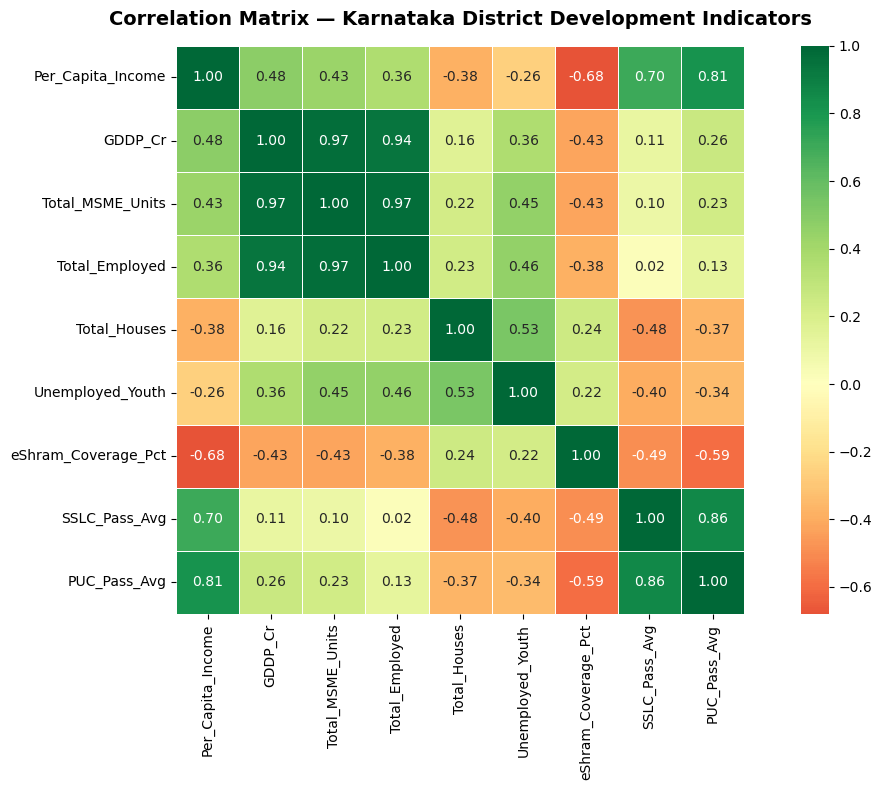


TOP 5 — Wealthiest Districts:
        District  Per_Capita_Income
Dakshina Kannada           626279.0
           Udupi           600683.0
 Bengaluru Urban           587524.0
  Chikkamagaluru           494787.0
      Shivamogga           389743.0

BOTTOM 5 — Poorest Districts:
  District  Per_Capita_Income
Kalaburagi           144449.0
  Yadagiri           164388.0
   Raichur           178888.0
    Koppal           181152.0
  Belagavi           183217.0

TOP 5 — Best Education (SSLC):
        District  SSLC_Pass_Avg
           Udupi         95.975
Dakshina Kannada         95.935
          Hassan         91.795
      Shivamogga         91.790
          Kodagu         91.225

BOTTOM 5 — Worst Education (SSLC):
   District  SSLC_Pass_Avg
 Kalaburagi         65.535
   Yadagiri         66.165
Chitradurga         76.065
      Bidar         76.520
    Raichur         77.090


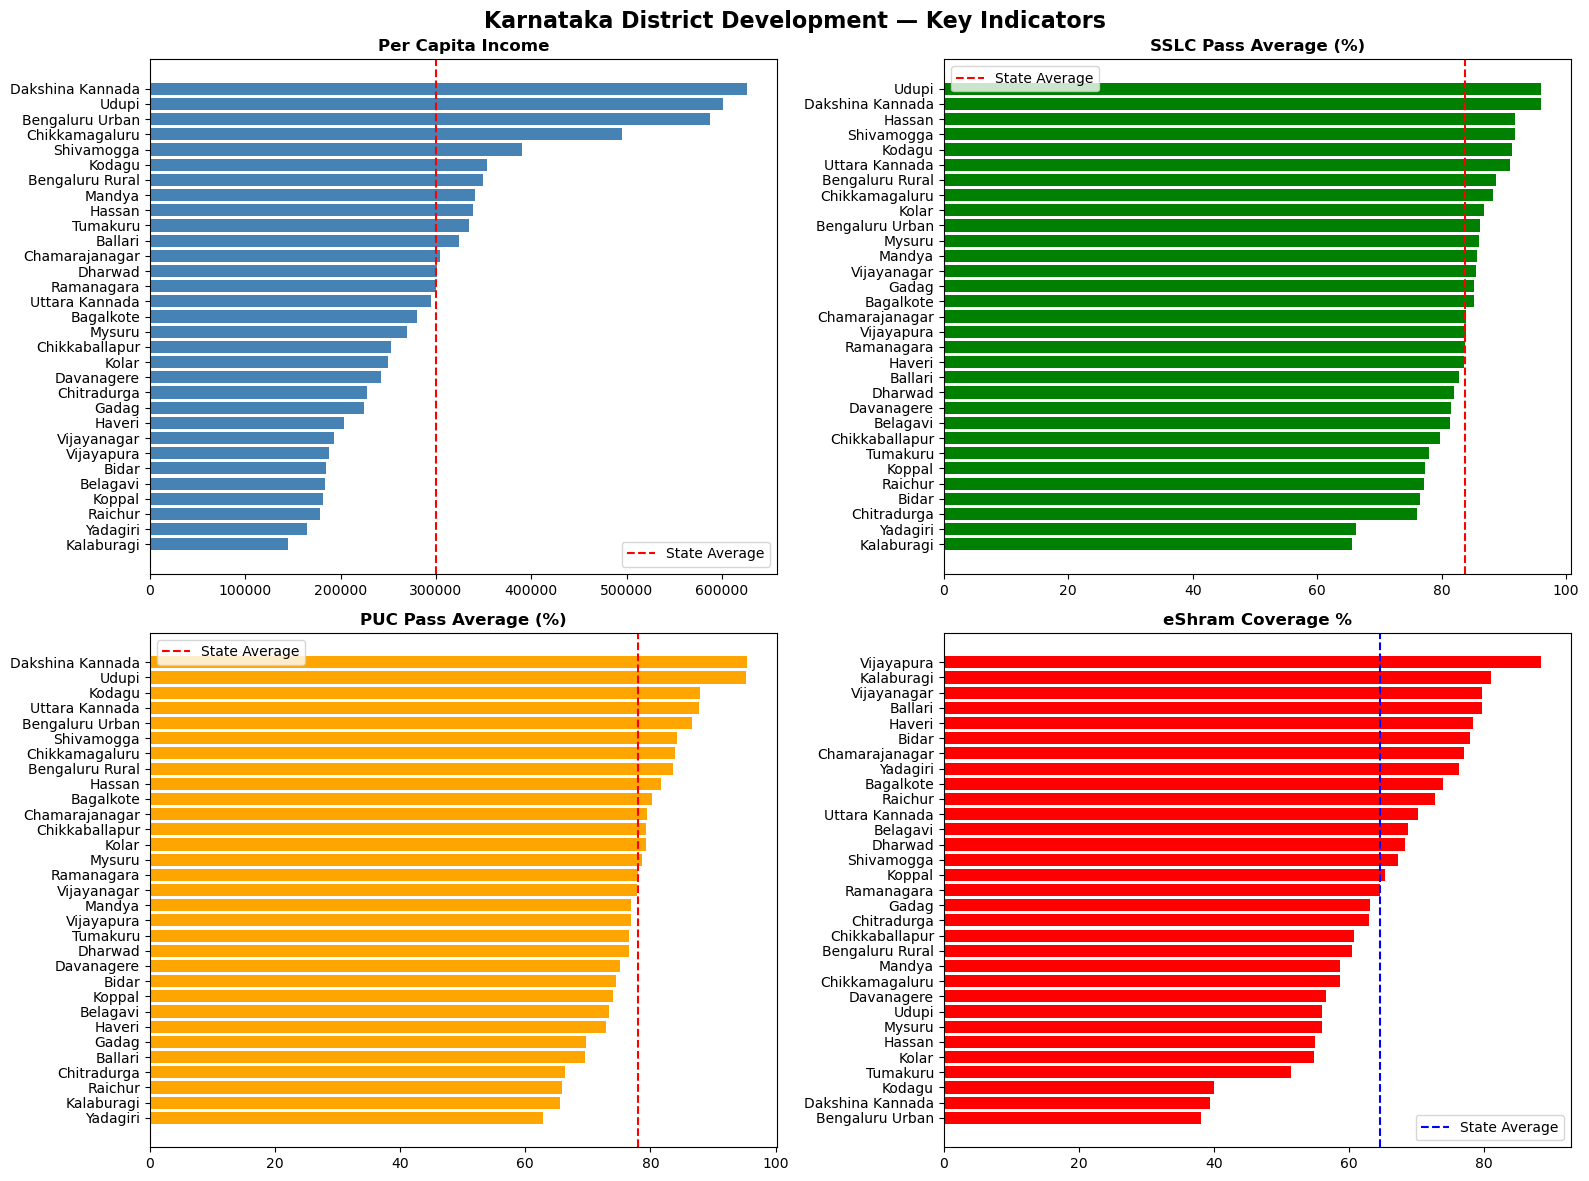

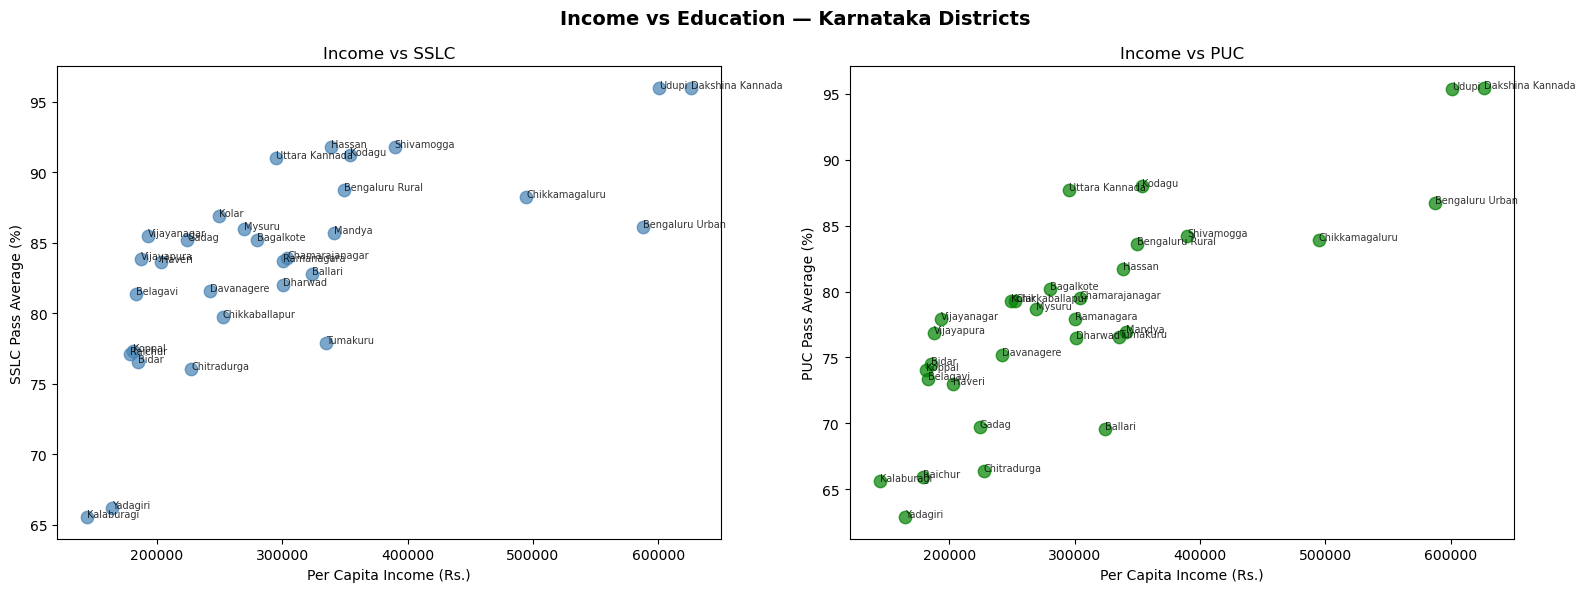

Section 4 EDA complete!


In [4]:
# ============================================================
# Section 4 — Exploratory Data Analysis (EDA)
# ============================================================

# 4.1 Basic Statistics
print("BASIC STATISTICS")
print("=" * 60)
print(master.describe().round(2))

# 4.2 Correlation Matrix
numeric_cols = ['Per_Capita_Income', 'GDDP_Cr', 'Total_MSME_Units',
                'Total_Employed', 'Total_Houses', 'Unemployed_Youth',
                'eShram_Coverage_Pct', 'SSLC_Pass_Avg', 'PUC_Pass_Avg']

corr = master[numeric_cols].corr().round(2)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix — Karnataka District Development Indicators',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.3 Top and Bottom Districts
print("\nTOP 5 — Wealthiest Districts:")
print(master[['District','Per_Capita_Income']].nlargest(
    5,'Per_Capita_Income').to_string(index=False))

print("\nBOTTOM 5 — Poorest Districts:")
print(master[['District','Per_Capita_Income']].nsmallest(
    5,'Per_Capita_Income').to_string(index=False))

print("\nTOP 5 — Best Education (SSLC):")
print(master[['District','SSLC_Pass_Avg']].nlargest(
    5,'SSLC_Pass_Avg').to_string(index=False))

print("\nBOTTOM 5 — Worst Education (SSLC):")
print(master[['District','SSLC_Pass_Avg']].nsmallest(
    5,'SSLC_Pass_Avg').to_string(index=False))

# 4.4 Bar Charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Karnataka District Development — Key Indicators',
             fontsize=16, fontweight='bold')

data1 = master[['District','Per_Capita_Income']].sort_values(
    'Per_Capita_Income', ascending=True)
axes[0,0].barh(data1['District'], data1['Per_Capita_Income'],
               color='steelblue')
axes[0,0].axvline(master['Per_Capita_Income'].mean(),
                  color='red', linestyle='--', label='State Average')
axes[0,0].set_title('Per Capita Income', fontweight='bold')
axes[0,0].legend()

data2 = master[['District','SSLC_Pass_Avg']].sort_values(
    'SSLC_Pass_Avg', ascending=True)
axes[0,1].barh(data2['District'], data2['SSLC_Pass_Avg'],
               color='green')
axes[0,1].axvline(master['SSLC_Pass_Avg'].mean(),
                  color='red', linestyle='--', label='State Average')
axes[0,1].set_title('SSLC Pass Average (%)', fontweight='bold')
axes[0,1].legend()

data3 = master[['District','PUC_Pass_Avg']].sort_values(
    'PUC_Pass_Avg', ascending=True)
axes[1,0].barh(data3['District'], data3['PUC_Pass_Avg'],
               color='orange')
axes[1,0].axvline(master['PUC_Pass_Avg'].mean(),
                  color='red', linestyle='--', label='State Average')
axes[1,0].set_title('PUC Pass Average (%)', fontweight='bold')
axes[1,0].legend()

data4 = master[['District','eShram_Coverage_Pct']].sort_values(
    'eShram_Coverage_Pct', ascending=True)
axes[1,1].barh(data4['District'], data4['eShram_Coverage_Pct'],
               color='red')
axes[1,1].axvline(master['eShram_Coverage_Pct'].mean(),
                  color='blue', linestyle='--', label='State Average')
axes[1,1].set_title('eShram Coverage %', fontweight='bold')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('district_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.5 Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Income vs Education — Karnataka Districts',
             fontsize=14, fontweight='bold')

axes[0].scatter(master['Per_Capita_Income'],
                master['SSLC_Pass_Avg'],
                color='steelblue', s=80, alpha=0.7)
for i, row in master.iterrows():
    axes[0].annotate(row['District'],
                     (row['Per_Capita_Income'],
                      row['SSLC_Pass_Avg']),
                     fontsize=7, alpha=0.8)
axes[0].set_xlabel('Per Capita Income (Rs.)')
axes[0].set_ylabel('SSLC Pass Average (%)')
axes[0].set_title('Income vs SSLC')

axes[1].scatter(master['Per_Capita_Income'],
                master['PUC_Pass_Avg'],
                color='green', s=80, alpha=0.7)
for i, row in master.iterrows():
    axes[1].annotate(row['District'],
                     (row['Per_Capita_Income'],
                      row['PUC_Pass_Avg']),
                     fontsize=7, alpha=0.8)
axes[1].set_xlabel('Per Capita Income (Rs.)')
axes[1].set_ylabel('PUC Pass Average (%)')
axes[1].set_title('Income vs PUC')

plt.tight_layout()
plt.savefig('income_vs_education.png', dpi=150, bbox_inches='tight')
plt.show()
print("Section 4 EDA complete!")

KARNATAKA DISTRICT DEVELOPMENT INDEX
        District  DDI_Score  DDI_Rank
 Bengaluru Urban      79.79         1
Dakshina Kannada      75.23         2
           Udupi      69.80         3
          Kodagu      54.77         4
  Chikkamagaluru      54.40         5
 Bengaluru Rural      51.21         6
          Hassan      49.75         7
      Shivamogga      49.21         8
          Mysuru      45.42         9
  Uttara Kannada      44.69        10
        Tumakuru      43.20        11
          Mandya      42.74        12
           Kolar      41.40        13
      Ramanagara      39.79        14
  Chamarajanagar      39.06        15
       Bagalkote      37.88        16
  Chikkaballapur      36.40        17
         Dharwad      35.84        18
      Davanagere      35.36        19
         Ballari      34.05        20
           Gadag      32.28        21
     Vijayanagar      31.19        22
     Chitradurga      29.46        23
      Vijayapura      28.39        24
          Hav

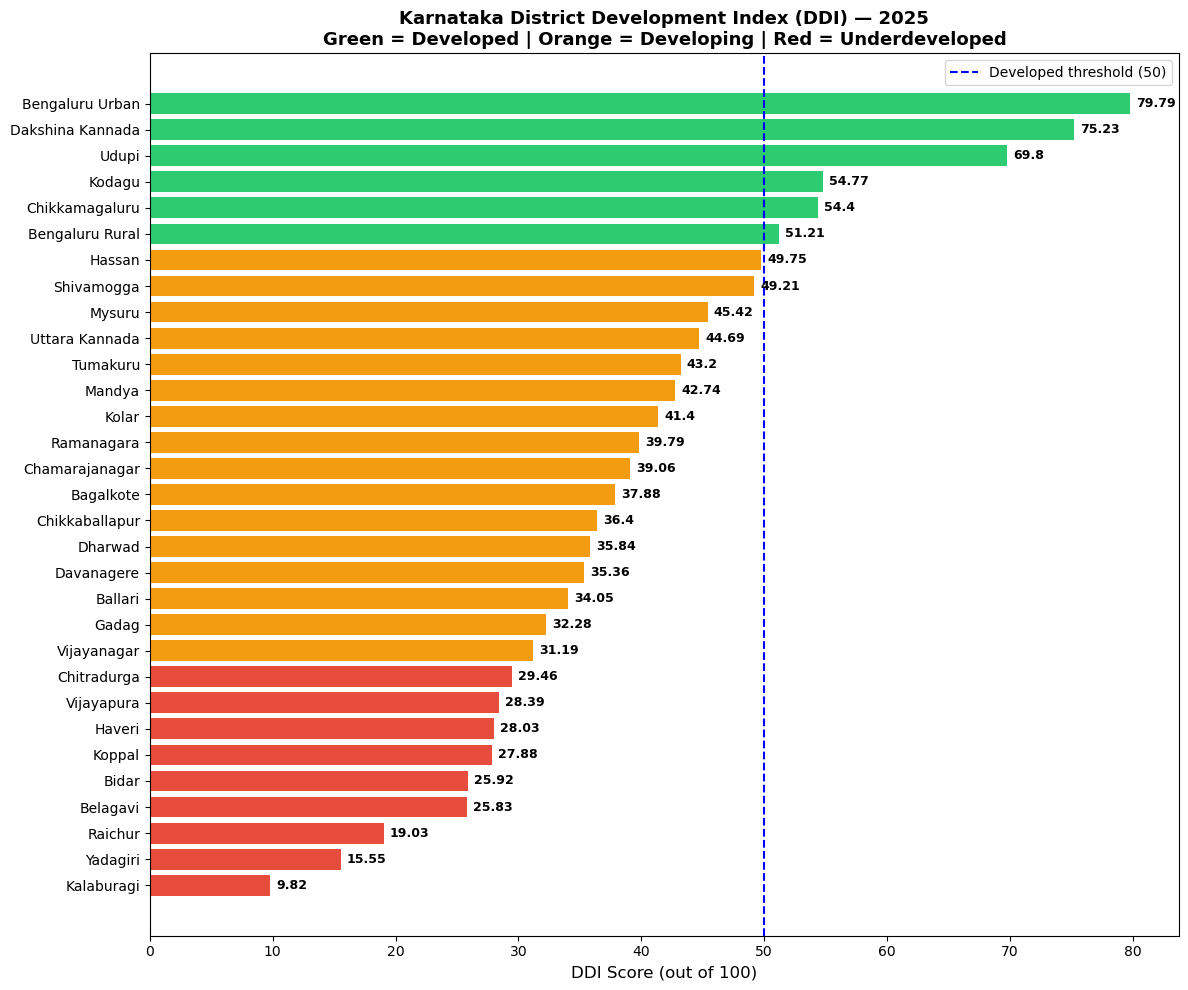

Section 5 DDI complete!


In [5]:
# ============================================================
# Section 5 — District Development Index (DDI)
# ============================================================

# 5.1 Normalize indicators
indicators = ['Per_Capita_Income', 'Total_Employed', 'Total_Houses',
              'Unemployed_Youth', 'eShram_Coverage_Pct',
              'SSLC_Pass_Avg', 'PUC_Pass_Avg']

scaler = MinMaxScaler()
normalized = pd.DataFrame(
    scaler.fit_transform(master[indicators]),
    columns=indicators
)

# Flip negative indicators
normalized['Unemployed_Youth']    = 1 - normalized['Unemployed_Youth']
normalized['eShram_Coverage_Pct'] = 1 - normalized['eShram_Coverage_Pct']

# 5.2 Apply weights
weights = {
    'Per_Capita_Income'   : 0.25,
    'Total_Employed'      : 0.20,
    'SSLC_Pass_Avg'       : 0.15,
    'PUC_Pass_Avg'        : 0.15,
    'eShram_Coverage_Pct' : 0.10,
    'Unemployed_Youth'    : 0.10,
    'Total_Houses'        : 0.05,
}

# 5.3 Calculate DDI Score
master['DDI_Score'] = sum(
    normalized[col] * weight
    for col, weight in weights.items()
) * 100
master['DDI_Score'] = master['DDI_Score'].round(2)

# 5.4 Rank districts
master['DDI_Rank'] = master['DDI_Score'].rank(
    ascending=False).astype(int)

# 5.5 Print results
result = master[['District','DDI_Score','DDI_Rank']].sort_values(
    'DDI_Rank')
print("KARNATAKA DISTRICT DEVELOPMENT INDEX")
print("=" * 45)
print(result.to_string(index=False))

# 5.6 Visualize DDI Scores
plt.figure(figsize=(12, 10))
data_ddi = result.sort_values('DDI_Score', ascending=True)
colors = ['#2ecc71' if x >= 50 else '#f39c12'
          if x >= 30 else '#e74c3c'
          for x in data_ddi['DDI_Score']]

bars = plt.barh(data_ddi['District'],
                data_ddi['DDI_Score'], color=colors)
for bar, score in zip(bars, data_ddi['DDI_Score']):
    plt.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             f'{score}', va='center',
             fontsize=9, fontweight='bold')

plt.axvline(x=50, color='blue', linestyle='--',
            linewidth=1.5, label='Developed threshold (50)')
plt.xlabel('DDI Score (out of 100)', fontsize=12)
plt.title('Karnataka District Development Index (DDI) — 2025\n'
          'Green = Developed | Orange = Developing | '
          'Red = Underdeveloped',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('DDI_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Section 5 DDI complete!")

MODEL 1 — K-MEANS CLUSTERING


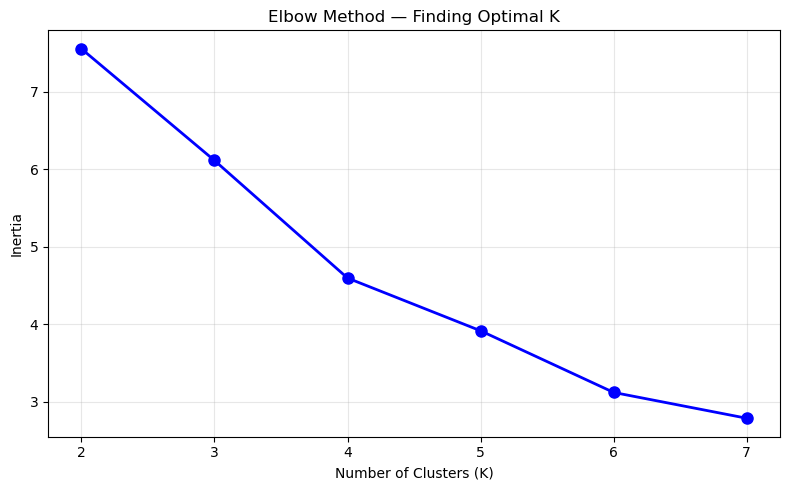

Districts by Development Tier:

Highly Developed (1 districts):
Bengaluru Urban

Developing (10 districts):
Bengaluru Rural, Chikkamagaluru, Dakshina Kannada, Hassan, Kodagu, Kolar, Mandya, Shivamogga, Udupi, Uttara Kannada

Underdeveloped (20 districts):
Bagalkote, Ballari, Belagavi, Bidar, Chamarajanagar, Chikkaballapur, Chitradurga, Davanagere, Dharwad, Gadag, Haveri, Kalaburagi, Koppal, Mysuru, Raichur, Ramanagara, Tumakuru, Vijayanagar, Vijayapura, Yadagiri


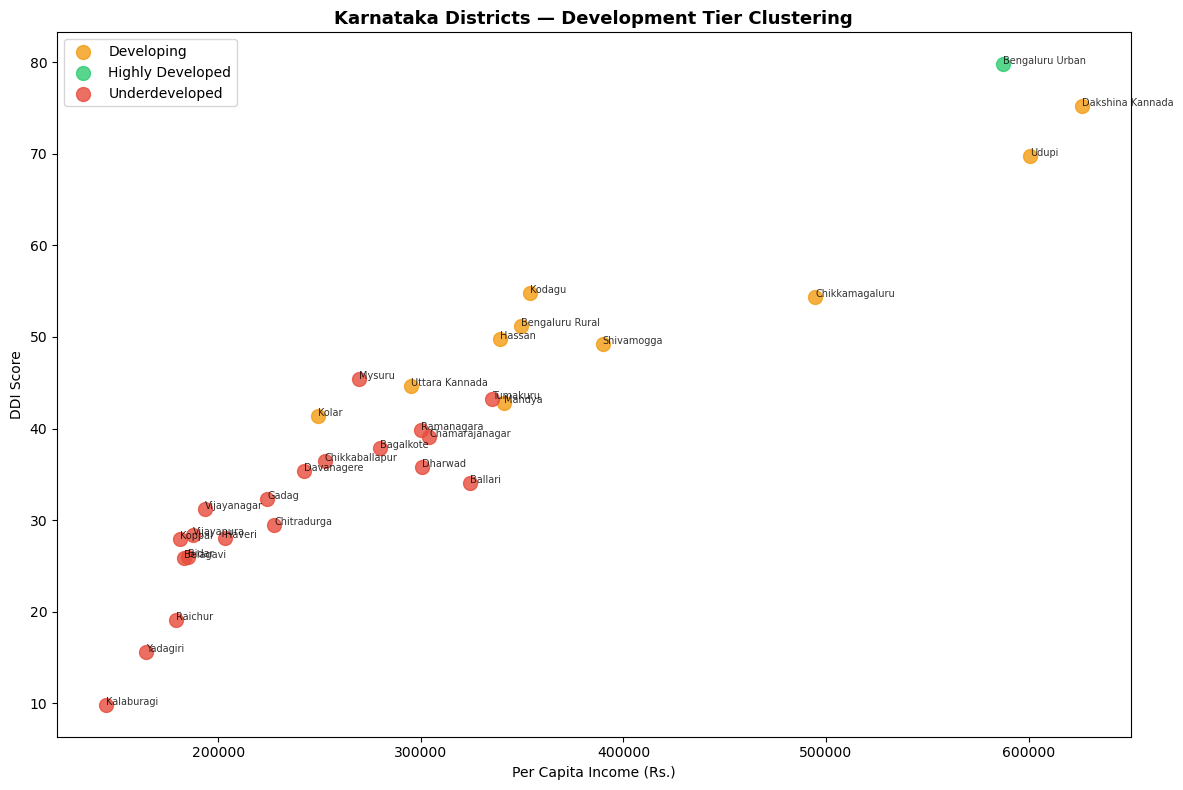


MODEL 2 — RANDOM FOREST REGRESSION
R2 Score : 0.9826
MAE      : 1.4264
CV Mean R2: 0.841

Feature Importance:
            Feature  Importance
  Per_Capita_Income    0.606391
       PUC_Pass_Avg    0.173068
      SSLC_Pass_Avg    0.146321
eShram_Coverage_Pct    0.041732
   Unemployed_Youth    0.012882
       Total_Houses    0.012025
     Total_Employed    0.007581


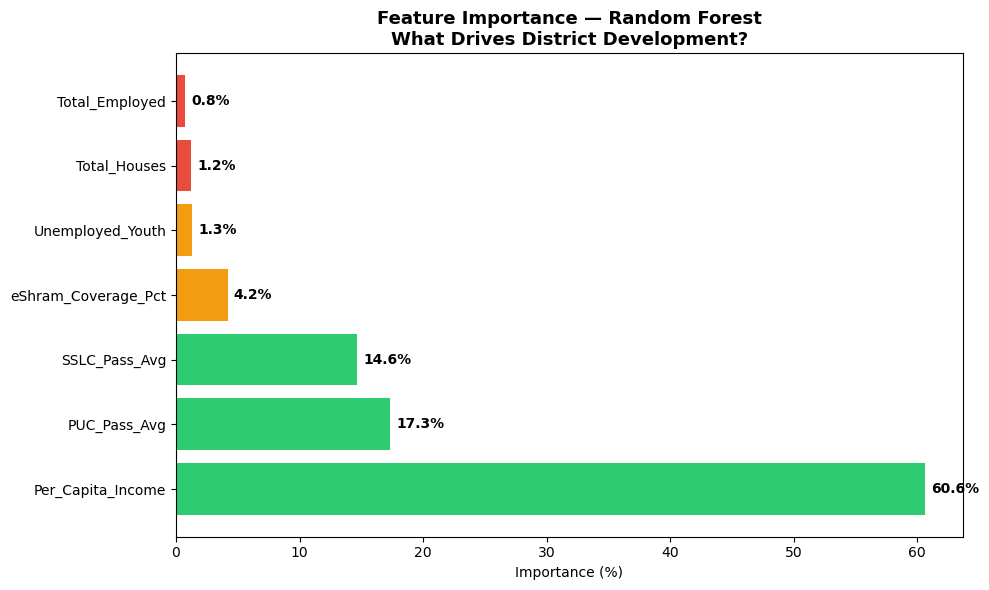


MODEL 3 — RANDOM FOREST CLASSIFICATION
Classification Report:
                  precision    recall  f1-score   support

      Developing       1.00      1.00      1.00        10
Highly Developed       1.00      1.00      1.00         1
  Underdeveloped       1.00      1.00      1.00        20

        accuracy                           1.00        31
       macro avg       1.00      1.00      1.00        31
    weighted avg       1.00      1.00      1.00        31



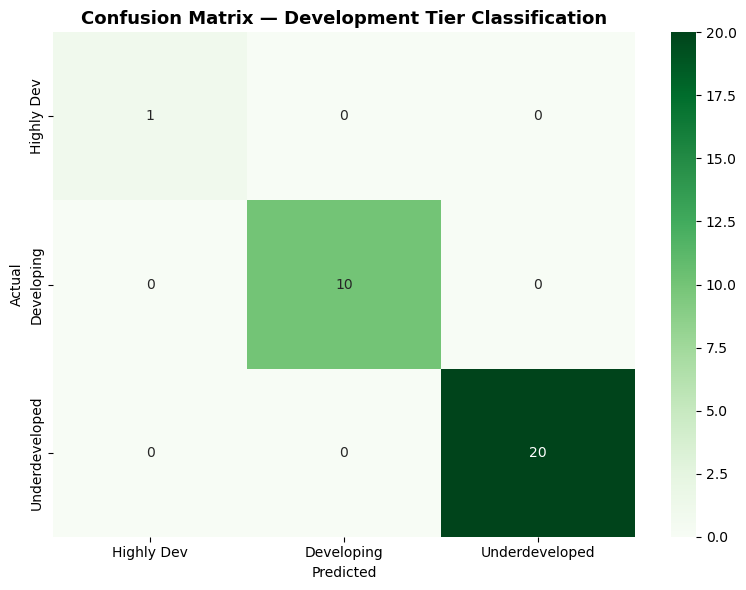


MODEL 4 — OLS REGRESSION
                            OLS Regression Results                            
Dep. Variable:              DDI_Score   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.625e+07
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           2.60e-84
Time:                        12:25:37   Log-Likelihood:                 137.17
No. Observations:                  31   AIC:                            -258.3
Df Residuals:                      23   BIC:                            -246.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const   

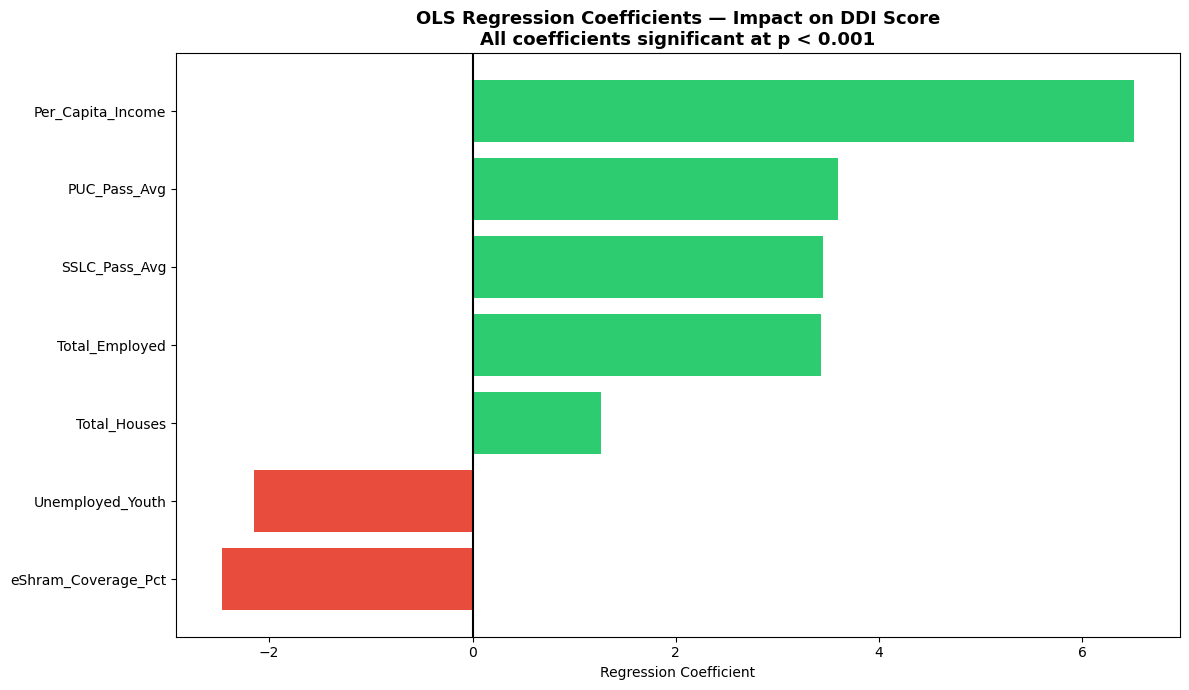

Section 6 ML Models complete!


In [6]:
# ============================================================
# Section 6 — Machine Learning Models
# ============================================================

# 6.1 K-Means Clustering
print("MODEL 1 — K-MEANS CLUSTERING")
print("=" * 45)

X = normalized[['Per_Capita_Income', 'Total_Employed',
                'Total_Houses', 'Unemployed_Youth',
                'eShram_Coverage_Pct', 'SSLC_Pass_Avg',
                'PUC_Pass_Avg']]

# Elbow method
inertia = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal K')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Apply K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
master['Cluster'] = kmeans.fit_predict(X)

# Label clusters
cluster_labels = {
    master.groupby('Cluster')['DDI_Score'].mean().idxmax(): 'Highly Developed',
    master.groupby('Cluster')['DDI_Score'].mean().idxmin(): 'Underdeveloped',
}
for k in range(3):
    if k not in cluster_labels:
        cluster_labels[k] = 'Developing'
master['Development_Tier'] = master['Cluster'].map(cluster_labels)

print("Districts by Development Tier:")
for tier in ['Highly Developed', 'Developing', 'Underdeveloped']:
    districts = master[master['Development_Tier']==tier]['District'].tolist()
    print(f"\n{tier} ({len(districts)} districts):")
    print(', '.join(districts))

# Cluster visualization
plt.figure(figsize=(12, 8))
colors = {'Highly Developed':'#2ecc71',
          'Developing'      :'#f39c12',
          'Underdeveloped'  :'#e74c3c'}
for tier, group in master.groupby('Development_Tier'):
    plt.scatter(group['Per_Capita_Income'],
                group['DDI_Score'],
                label=tier, color=colors[tier],
                s=100, alpha=0.8)
    for _, row in group.iterrows():
        plt.annotate(row['District'],
                     (row['Per_Capita_Income'],
                      row['DDI_Score']),
                     fontsize=7, alpha=0.8)
plt.xlabel('Per Capita Income (Rs.)')
plt.ylabel('DDI Score')
plt.title('Karnataka Districts — Development Tier Clustering',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6.2 Random Forest Regression ────────────────────────────
print("\nMODEL 2 — RANDOM FOREST REGRESSION")
print("=" * 45)

X_rf = master[['Per_Capita_Income', 'Total_Employed',
               'Total_Houses', 'Unemployed_Youth',
               'eShram_Coverage_Pct', 'SSLC_Pass_Avg',
               'PUC_Pass_Avg']]
y_rf = master['DDI_Score']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_rf, y_rf)
y_pred = rf_model.predict(X_rf)

print(f"R2 Score : {r2_score(y_rf, y_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_rf, y_pred):.4f}")

cv_scores = cross_val_score(rf_model, X_rf, y_rf, cv=5, scoring='r2')
print(f"CV Mean R2: {cv_scores.mean():.3f}")

importance = pd.DataFrame({
    'Feature'   : X_rf.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance.to_string(index=False))

# Feature importance chart
plt.figure(figsize=(10, 6))
colors_fi = ['#2ecc71' if i < 3 else '#f39c12'
             if i < 5 else '#e74c3c'
             for i in range(len(importance))]
plt.barh(importance['Feature'],
         importance['Importance']*100, color=colors_fi)
for i, val in enumerate(importance['Importance']*100):
    plt.text(val+0.5, i, f'{val:.1f}%',
             va='center', fontweight='bold')
plt.xlabel('Importance (%)')
plt.title('Feature Importance — Random Forest\n'
          'What Drives District Development?',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6.3 Random Forest Classification ────────────────────────
print("\nMODEL 3 — RANDOM FOREST CLASSIFICATION")
print("=" * 45)

X_clf = X_rf.copy()
y_clf = master['Development_Tier']

clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_clf, y_clf)
y_pred_clf = clf_model.predict(X_clf)

print("Classification Report:")
print(classification_report(y_clf, y_pred_clf))

cm = confusion_matrix(y_clf, y_pred_clf,
                      labels=['Highly Developed',
                              'Developing',
                              'Underdeveloped'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Highly Dev','Developing','Underdeveloped'],
            yticklabels=['Highly Dev','Developing','Underdeveloped'])
plt.title('Confusion Matrix — Development Tier Classification',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6.4 OLS Regression ──────────────────────────────────────
print("\nMODEL 4 — OLS REGRESSION")
print("=" * 45)

X_ols = master[['Per_Capita_Income', 'Total_Employed',
                'Total_Houses', 'Unemployed_Youth',
                'eShram_Coverage_Pct', 'SSLC_Pass_Avg',
                'PUC_Pass_Avg']]
scaler_ols  = StandardScaler()
X_scaled    = scaler_ols.fit_transform(X_ols)
X_scaled    = pd.DataFrame(X_scaled, columns=X_ols.columns)
X_scaled    = sm.add_constant(X_scaled)
ols_model   = sm.OLS(y_rf, X_scaled).fit()
print(ols_model.summary())

# OLS coefficients chart
coef_df = pd.DataFrame({
    'Indicator'  : X_ols.columns,
    'Coefficient': ols_model.params[1:]
}).sort_values('Coefficient', ascending=True)

colors_ols = ['#e74c3c' if x < 0 else '#2ecc71'
              for x in coef_df['Coefficient']]
plt.figure(figsize=(12, 7))
plt.barh(coef_df['Indicator'],
         coef_df['Coefficient'], color=colors_ols)
plt.axvline(x=0, color='black', linewidth=1.5)
plt.xlabel('Regression Coefficient')
plt.title('OLS Regression Coefficients — Impact on DDI Score\n'
          'All coefficients significant at p < 0.001',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ols_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print("Section 6 ML Models complete!")

ANALYSIS 1 — TIME SERIES EDUCATION TREND
Top 3 Most Improved (SSLC):
   District  SSLC_Change
     Koppal         3.16
Vijayanagar         2.55
      Kolar         1.57

Top 3 Most Declined (SSLC):
   District  SSLC_Change
 Kalaburagi       -17.29
Chitradurga       -11.23
   Tumakuru       -10.82


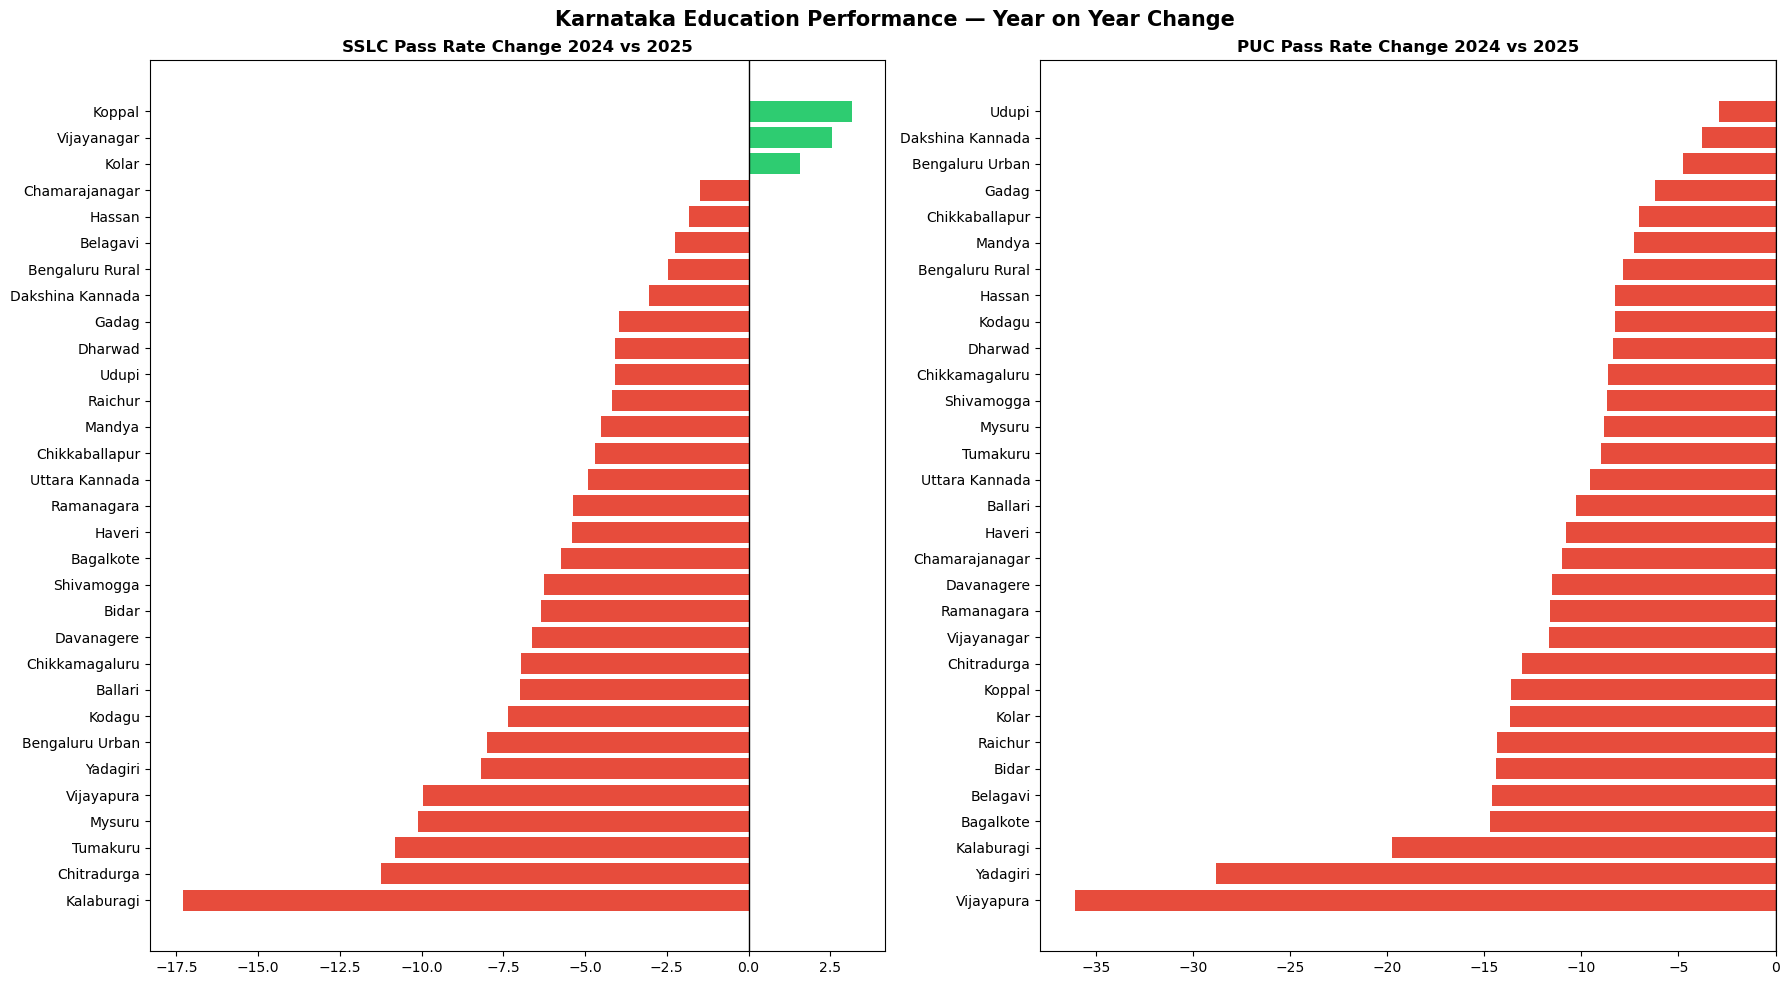


ANALYSIS 2 — REGIONAL ANALYSIS
                   Avg_DDI  Avg_Income  Avg_SSLC  Avg_PUC  Avg_eShram  Total_Districts
Region                                                                                
Coastal Karnataka    63.24   507359.33     94.29    92.85       55.27                3
Malnad Karnataka     51.80   442265.00     90.01    84.06       62.94                2
South Karnataka      47.59   334654.43     85.60    80.75       56.06               11
Central Karnataka    32.41   234856.50     78.81    70.80       59.83                2
North Karnataka      27.05   211524.54     79.39    72.31       74.89               13


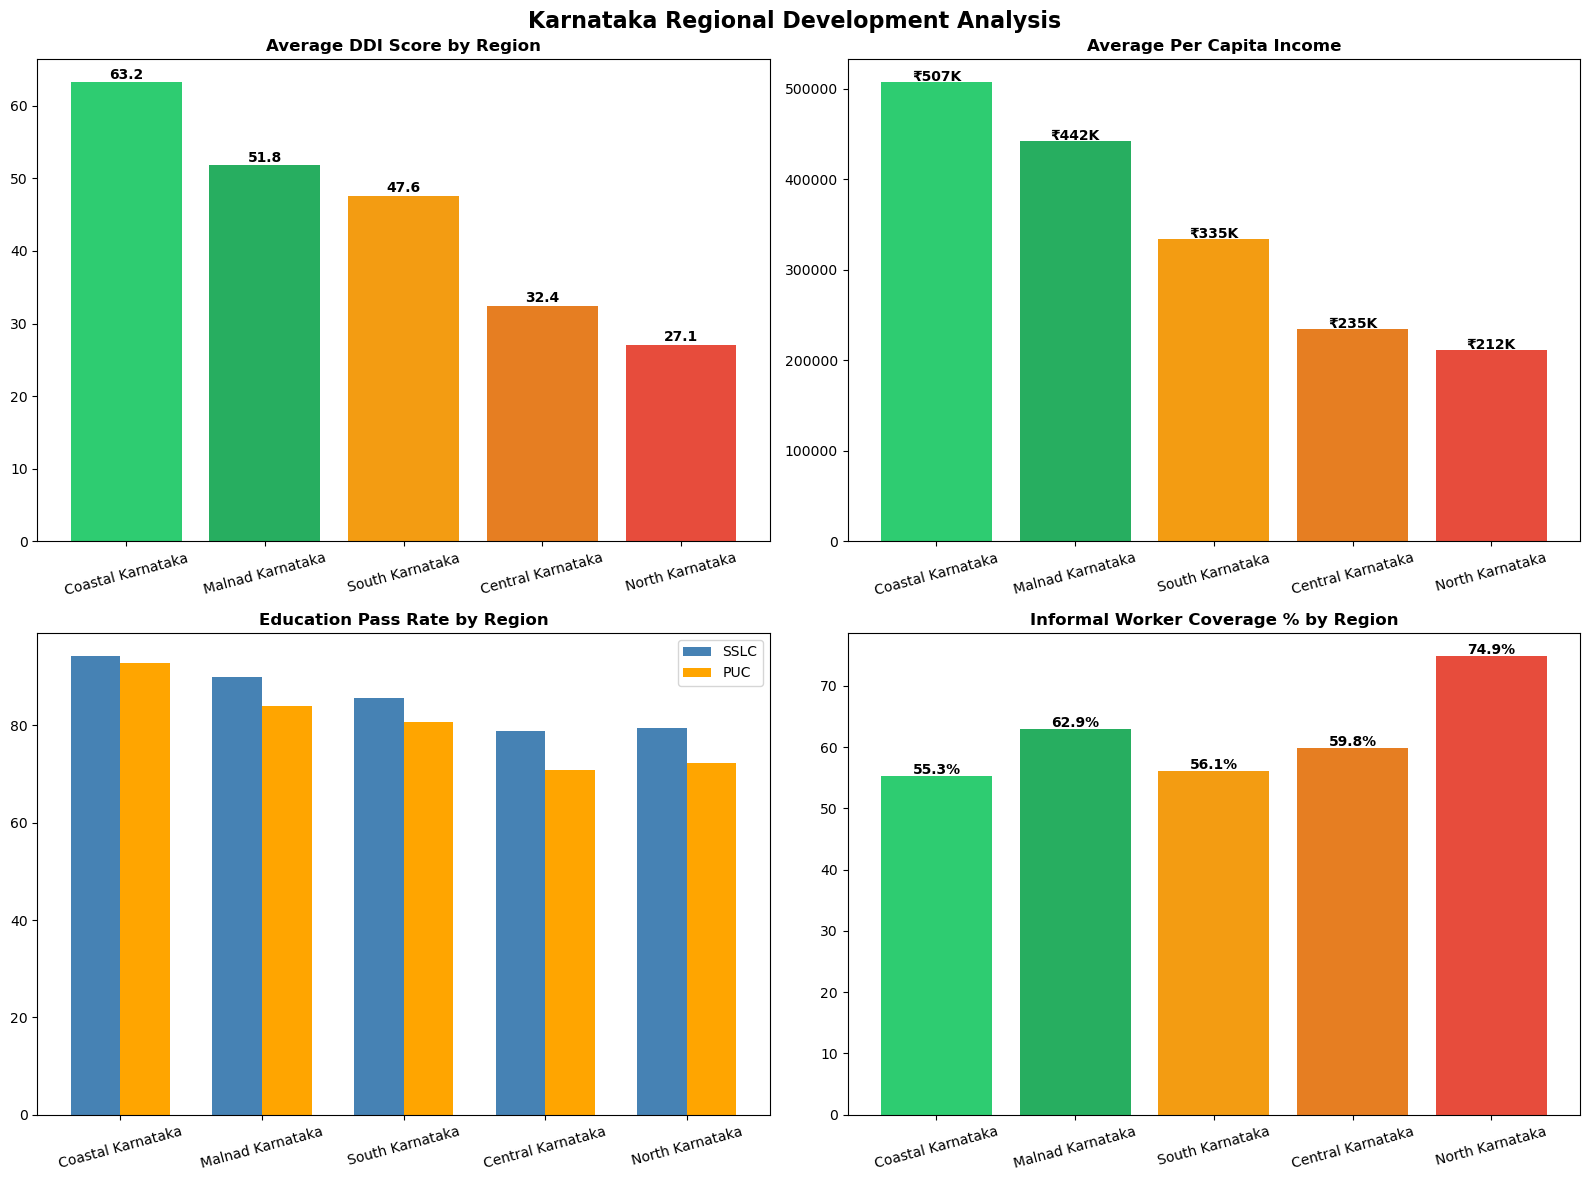


ANALYSIS 3 — GINI COEFFICIENT
Indicator                      Gini          Level
--------------------------------------------------
DDI Score                    0.2151       Moderate
Per Capita Income            0.2193       Moderate
SSLC Pass Rate               0.0454            Low
PUC Pass Rate                0.0560            Low
MSME Employment              0.4044      Very High
eShram Coverage              0.1084            Low


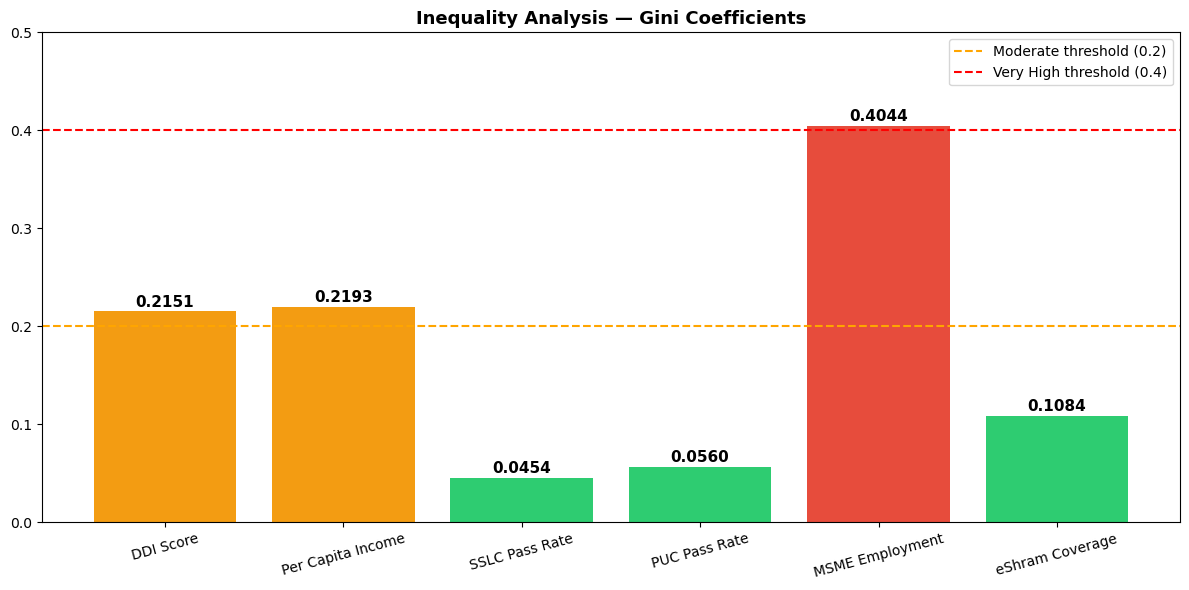


ANALYSIS 4 — SENSITIVITY ANALYSIS
        District  Original Weights  Education Heavy  Economy Heavy
 Bengaluru Urban         79.787038        78.069428      87.810958
Dakshina Kannada         75.233050        80.647508      70.861560
           Udupi         69.800670        75.658660      64.770871
          Kodagu         54.768722        61.569403      41.354603
  Chikkamagaluru         54.400061        56.527251      49.468358
 Bengaluru Rural         51.213347        55.221379      43.096527
          Hassan         49.749909        55.530838      41.113700
      Shivamogga         49.206512        55.364930      42.836811
          Mysuru         45.415444        50.354805      35.150075
  Uttara Kannada         44.694276        53.509384      33.706434
        Tumakuru         43.202244        43.210752      36.051625
          Mandya         42.735230        45.083739      35.313921
           Kolar         41.399518        46.451228      29.601448
      Ramanagara         39

In [7]:
# ============================================================
# Section 7 — Advanced Analysis
# ============================================================

# 7.1 Time Series — Education Trend
print("ANALYSIS 1 — TIME SERIES EDUCATION TREND")
print("=" * 45)

master['SSLC_Change'] = master['SSLC_Pass_2025'] - master['SSLC_Pass_2024']
master['PUC_Change']  = master['PUC_Pass_2025']  - master['PUC_Pass_2024']

print("Top 3 Most Improved (SSLC):")
print(master[['District','SSLC_Change']].nlargest(
    3,'SSLC_Change').to_string(index=False))
print("\nTop 3 Most Declined (SSLC):")
print(master[['District','SSLC_Change']].nsmallest(
    3,'SSLC_Change').to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
sslc_sorted = master[['District','SSLC_Change']].sort_values(
    'SSLC_Change', ascending=True)
puc_sorted  = master[['District','PUC_Change']].sort_values(
    'PUC_Change', ascending=True)

axes[0].barh(sslc_sorted['District'], sslc_sorted['SSLC_Change'],
             color=['#e74c3c' if x < 0 else '#2ecc71'
                    for x in sslc_sorted['SSLC_Change']])
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_title('SSLC Pass Rate Change 2024 vs 2025',
                  fontweight='bold')

axes[1].barh(puc_sorted['District'], puc_sorted['PUC_Change'],
             color=['#e74c3c' if x < 0 else '#2ecc71'
                    for x in puc_sorted['PUC_Change']])
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_title('PUC Pass Rate Change 2024 vs 2025',
                  fontweight='bold')

plt.suptitle('Karnataka Education Performance — Year on Year Change',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('education_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7.2 Regional Analysis ────────────────────────────────────
print("\nANALYSIS 2 — REGIONAL ANALYSIS")
print("=" * 45)

region_map = {
    'Bengaluru Urban' :'South Karnataka',
    'Bengaluru Rural' :'South Karnataka',
    'Ramanagara'      :'South Karnataka',
    'Mysuru'          :'South Karnataka',
    'Mandya'          :'South Karnataka',
    'Chamarajanagar'  :'South Karnataka',
    'Hassan'          :'South Karnataka',
    'Kodagu'          :'South Karnataka',
    'Kolar'           :'South Karnataka',
    'Chikkaballapur'  :'South Karnataka',
    'Tumakuru'        :'South Karnataka',
    'Dakshina Kannada':'Coastal Karnataka',
    'Udupi'           :'Coastal Karnataka',
    'Uttara Kannada'  :'Coastal Karnataka',
    'Shivamogga'      :'Malnad Karnataka',
    'Chikkamagaluru'  :'Malnad Karnataka',
    'Davanagere'      :'Central Karnataka',
    'Chitradurga'     :'Central Karnataka',
    'Dharwad'         :'North Karnataka',
    'Gadag'           :'North Karnataka',
    'Haveri'          :'North Karnataka',
    'Belagavi'        :'North Karnataka',
    'Bagalkote'       :'North Karnataka',
    'Vijayapura'      :'North Karnataka',
    'Ballari'         :'North Karnataka',
    'Vijayanagar'     :'North Karnataka',
    'Koppal'          :'North Karnataka',
    'Raichur'         :'North Karnataka',
    'Kalaburagi'      :'North Karnataka',
    'Bidar'           :'North Karnataka',
    'Yadagiri'        :'North Karnataka',
}
master['Region'] = master['District'].map(region_map)

regional = master.groupby('Region').agg({
    'DDI_Score'          : 'mean',
    'Per_Capita_Income'  : 'mean',
    'SSLC_Pass_Avg'      : 'mean',
    'PUC_Pass_Avg'       : 'mean',
    'eShram_Coverage_Pct': 'mean',
    'District'           : 'count'
}).round(2)
regional.columns = ['Avg_DDI','Avg_Income','Avg_SSLC',
                    'Avg_PUC','Avg_eShram','Total_Districts']
regional = regional.sort_values('Avg_DDI', ascending=False)
print(regional.to_string())

regions  = regional.index.tolist()
colors_r = ['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Karnataka Regional Development Analysis',
             fontsize=16, fontweight='bold')

axes[0,0].bar(regions, regional['Avg_DDI'], color=colors_r)
axes[0,0].set_title('Average DDI Score by Region', fontweight='bold')
for i, v in enumerate(regional['Avg_DDI']):
    axes[0,0].text(i, v+0.5, f'{v:.1f}', ha='center', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=15)

axes[0,1].bar(regions, regional['Avg_Income'], color=colors_r)
axes[0,1].set_title('Average Per Capita Income', fontweight='bold')
for i, v in enumerate(regional['Avg_Income']):
    axes[0,1].text(i, v+1000, f'₹{v/1000:.0f}K',
                   ha='center', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=15)

x     = range(len(regions))
width = 0.35
axes[1,0].bar([i-width/2 for i in x], regional['Avg_SSLC'],
              width, label='SSLC', color='steelblue')
axes[1,0].bar([i+width/2 for i in x], regional['Avg_PUC'],
              width, label='PUC', color='orange')
axes[1,0].set_title('Education Pass Rate by Region', fontweight='bold')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(regions, rotation=15)
axes[1,0].legend()

axes[1,1].bar(regions, regional['Avg_eShram'], color=colors_r)
axes[1,1].set_title('Informal Worker Coverage % by Region',
                    fontweight='bold')
for i, v in enumerate(regional['Avg_eShram']):
    axes[1,1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('regional_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7.3 Gini Coefficient ─────────────────────────────────────
print("\nANALYSIS 3 — GINI COEFFICIENT")
print("=" * 45)

def gini_coefficient(values):
    values = np.sort(np.array(values))
    n      = len(values)
    index  = np.arange(1, n+1)
    return round((2*np.sum(index*values))/(n*np.sum(values))-(n+1)/n, 4)

gini_data = {
    'DDI Score'        : master['DDI_Score'],
    'Per Capita Income': master['Per_Capita_Income'],
    'SSLC Pass Rate'   : master['SSLC_Pass_Avg'],
    'PUC Pass Rate'    : master['PUC_Pass_Avg'],
    'MSME Employment'  : master['Total_Employed'],
    'eShram Coverage'  : master['eShram_Coverage_Pct'],
}

print(f"{'Indicator':<25}{'Gini':>10}{'Level':>15}")
print("-" * 50)
gini_results = {}
for name, values in gini_data.items():
    gini = gini_coefficient(values)
    gini_results[name] = gini
    level = 'Low' if gini < 0.2 else 'Moderate' if gini < 0.3 \
            else 'High' if gini < 0.4 else 'Very High'
    print(f"{name:<25}{gini:>10.4f}{level:>15}")

colors_g = ['#e74c3c' if v >= 0.4 else '#f39c12'
            if v >= 0.2 else '#2ecc71'
            for v in gini_results.values()]
plt.figure(figsize=(12, 6))
bars = plt.bar(gini_results.keys(),
               gini_results.values(), color=colors_g)
for bar, val in zip(bars, gini_results.values()):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.005,
             f'{val:.4f}', ha='center',
             fontweight='bold', fontsize=11)
plt.axhline(y=0.2, color='orange', linestyle='--',
            label='Moderate threshold (0.2)')
plt.axhline(y=0.4, color='red', linestyle='--',
            label='Very High threshold (0.4)')
plt.title('Inequality Analysis — Gini Coefficients',
          fontsize=13, fontweight='bold')
plt.legend()
plt.xticks(rotation=15)
plt.ylim(0, 0.5)
plt.tight_layout()
plt.savefig('gini_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7.4 Sensitivity Analysis ─────────────────────────────────
print("\nANALYSIS 4 — SENSITIVITY ANALYSIS")
print("=" * 45)

scenarios = {
    'Original Weights': {'Per_Capita_Income':0.25,'Total_Employed':0.20,
                         'SSLC_Pass_Avg':0.15,'PUC_Pass_Avg':0.15,
                         'eShram_Coverage_Pct':0.10,
                         'Unemployed_Youth':0.10,'Total_Houses':0.05},
    'Education Heavy' : {'Per_Capita_Income':0.15,'Total_Employed':0.15,
                         'SSLC_Pass_Avg':0.25,'PUC_Pass_Avg':0.25,
                         'eShram_Coverage_Pct':0.10,
                         'Unemployed_Youth':0.05,'Total_Houses':0.05},
    'Economy Heavy'   : {'Per_Capita_Income':0.40,'Total_Employed':0.30,
                         'SSLC_Pass_Avg':0.10,'PUC_Pass_Avg':0.10,
                         'eShram_Coverage_Pct':0.05,
                         'Unemployed_Youth':0.03,'Total_Houses':0.02},
}

results_s = pd.DataFrame({'District':master['District']})
for name, w in scenarios.items():
    results_s[name] = sum(
        normalized[col]*weight for col, weight in w.items())*100

print(results_s.sort_values(
    'Original Weights', ascending=False).to_string(index=False))

# ── 7.5 Future Prediction Scenarios ──────────────────────────
print("\nANALYSIS 5 — FUTURE PREDICTION SCENARIOS")
print("=" * 45)

bottom5 = master.nsmallest(5,'DDI_Score')[
    ['District','DDI_Score','Per_Capita_Income',
     'Total_Employed','Total_Houses','Unemployed_Youth',
     'eShram_Coverage_Pct','SSLC_Pass_Avg','PUC_Pass_Avg']]

scenarios_future = []
for _, row in bottom5.iterrows():
    s1 = row.copy()
    s1['Scenario'] = '10% Income Increase'
    s1['Per_Capita_Income'] = row['Per_Capita_Income'] * 1.10

    s2 = row.copy()
    s2['Scenario'] = '10% Education Improvement'
    s2['SSLC_Pass_Avg'] = min(row['SSLC_Pass_Avg']*1.10, 100)
    s2['PUC_Pass_Avg']  = min(row['PUC_Pass_Avg']*1.10,  100)

    s3 = row.copy()
    s3['Scenario'] = 'Combined Improvement'
    s3['Per_Capita_Income'] = row['Per_Capita_Income'] * 1.10
    s3['SSLC_Pass_Avg'] = min(row['SSLC_Pass_Avg']*1.10, 100)
    s3['PUC_Pass_Avg']  = min(row['PUC_Pass_Avg']*1.10,  100)

    scenarios_future.extend([s1, s2, s3])

scenarios_df = pd.DataFrame(scenarios_future)
features = ['Per_Capita_Income','Total_Employed','Total_Houses',
            'Unemployed_Youth','eShram_Coverage_Pct',
            'SSLC_Pass_Avg','PUC_Pass_Avg']
scenarios_df['Predicted_DDI'] = rf_model.predict(
    scenarios_df[features]).round(2)

for district in bottom5['District']:
    current = master[master['District']==district]['DDI_Score'].values[0]
    print(f"\n{district} (Current DDI: {current})")
    for _, s in scenarios_df[
            scenarios_df['District']==district].iterrows():
        change = s['Predicted_DDI'] - current
        print(f"  {s['Scenario']:<30} → {s['Predicted_DDI']:>6} "
              f"(+{change:.2f})")

print("\nSection 7 Advanced Analysis complete!")

In [8]:
# ============================================================
# Section 8 — SQL Database
# ============================================================

print("SECTION 8 — SQL DATABASE")
print("=" * 45)

# Create database
conn = sqlite3.connect('karnataka_development.db')

# Save master to SQL
master.to_sql('district_development',
              conn, if_exists='replace', index=False)
print("Database created successfully!")

# Query 1 — Top 5 developed districts
print("\nQuery 1 — Top 5 Developed Districts:")
q1 = """
SELECT District, DDI_Score, DDI_Rank, Development_Tier
FROM district_development
ORDER BY DDI_Rank ASC LIMIT 5
"""
print(pd.read_sql(q1, conn))

# Query 2 — Bottom 5 districts
print("\nQuery 2 — Bottom 5 Underdeveloped Districts:")
q2 = """
SELECT District, DDI_Score, DDI_Rank,
       Per_Capita_Income, Development_Tier
FROM district_development
ORDER BY DDI_Rank DESC LIMIT 5
"""
print(pd.read_sql(q2, conn))

# Query 3 — Average by Development Tier
print("\nQuery 3 — Average Indicators by Development Tier:")
q3 = """
SELECT Development_Tier,
       COUNT(*) as Total_Districts,
       ROUND(AVG(DDI_Score),2) as Avg_DDI,
       ROUND(AVG(Per_Capita_Income),0) as Avg_Income,
       ROUND(AVG(SSLC_Pass_Avg),2) as Avg_SSLC,
       ROUND(AVG(PUC_Pass_Avg),2) as Avg_PUC,
       ROUND(AVG(eShram_Coverage_Pct),2) as Avg_eShram
FROM district_development
GROUP BY Development_Tier
ORDER BY Avg_DDI DESC
"""
print(pd.read_sql(q3, conn))

# Query 4 — Above state average income
print("\nQuery 4 — Districts Above State Average Income:")
q4 = """
SELECT District, Per_Capita_Income,
       DDI_Score, Development_Tier
FROM district_development
WHERE Per_Capita_Income > (
    SELECT AVG(Per_Capita_Income)
    FROM district_development)
ORDER BY Per_Capita_Income DESC
"""
print(pd.read_sql(q4, conn))

# Query 5 — Regional summary
print("\nQuery 5 — Regional Development Summary:")
q5 = """
SELECT Region,
       COUNT(*) as Districts,
       ROUND(AVG(DDI_Score),2) as Avg_DDI,
       ROUND(AVG(Per_Capita_Income),0) as Avg_Income
FROM district_development
GROUP BY Region
ORDER BY Avg_DDI DESC
"""
print(pd.read_sql(q5, conn))

conn.close()
print("\nDatabase connection closed!")

# ============================================================
# Section 9 — Export Final Dataset
# ============================================================

print("\nSECTION 9 — EXPORT")
print("=" * 45)

# Save final master dataset
master.to_csv('master_dataset_final.csv', index=False)
master.to_excel('karnataka_powerbi.xlsx', index=False)

print("Files exported:")
print("  master_dataset_final.csv")
print("  karnataka_powerbi.xlsx")
print(f"\nFinal dataset shape : {master.shape}")
print(f"Total columns       : {len(master.columns)}")
print(f"Total districts     : {len(master)}")
print(f"\nColumns: {list(master.columns)}")
print("\n" + "=" * 60)
print("PROJECT COMPLETE!")
print("Karnataka District Development Index")
print("Author  : Rohan Shetty | MSc Business Analytics")
print("Date    : September 2026")
print("Models  : K-Means, Random Forest, OLS Regression")
print("Districts: 31 | Indicators: 22 | Visualizations: 15")
print("=" * 60)

SECTION 8 — SQL DATABASE
Database created successfully!

Query 1 — Top 5 Developed Districts:
           District  DDI_Score  DDI_Rank  Development_Tier
0   Bengaluru Urban      79.79         1  Highly Developed
1  Dakshina Kannada      75.23         2        Developing
2             Udupi      69.80         3        Developing
3            Kodagu      54.77         4        Developing
4    Chikkamagaluru      54.40         5        Developing

Query 2 — Bottom 5 Underdeveloped Districts:
     District  DDI_Score  DDI_Rank  Per_Capita_Income Development_Tier
0  Kalaburagi       9.82        31           144449.0   Underdeveloped
1    Yadagiri      15.55        30           164388.0   Underdeveloped
2     Raichur      19.03        29           178888.0   Underdeveloped
3    Belagavi      25.83        28           183217.0   Underdeveloped
4       Bidar      25.92        27           185079.0   Underdeveloped

Query 3 — Average Indicators by Development Tier:
   Development_Tier  Total_Di